# LoVoCCS morphology: Searching for patterns in morphology parameter space

This is a 'discovery science' portion of the X-LoVoCCS project, where we compile our various measurements of LoVoCCS cluster morphology (from the direct X-ray ICM measurements, and our comparisons with optical/WL constraints) into a single morphology parameter space and seek to identify any 'clusters of galaxy clusters'.

That is to say, are there distinct groupings of galaxy clusters in the morphology space, and do those groupings have physical meaning?

## Main takeaways 

In summary:

* 

## Import Statements

In [39]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import os
from astropy.units import Quantity
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AffinityPropagation, KMeans
from sklearn.manifold import TSNE

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [2]:
# These are the random states used for dimensionality reduction
umap_rand_state = 4059
tsne_rand_state = 907

## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [3]:
morph_fig_path = "../../outputs/figures/positions_and_morphology/morph_par_space/"
os.makedirs(morph_fig_path, exist_ok=True)

## Cosmological model

We employ the same cosmological model utilized in the LoVoCCS-I & II analyses (Fu et al. [2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...933...84F/abstract), [2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)):

In [4]:
lovoccs_cosmo

LambdaCDM(name=None, H0=<Quantity 71. km / (Mpc s)>, Om0=0.2648, Ode0=0.7352, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0448)

## Loading data files

Important considerations for this dataset:

* Some clusters selected for LoVoCCS have been identified as multiple blended systems in the course of the X-LoVoCCS project - other LoVoCCS works may only have entries/have made measurements for the overall system.
* Not all LoVoCCS-II galaxy clusters have XMM data available - as such we will not yet have measured X-ray centroids for them.

### X-LoVoCCS-I base sample

In [5]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


### X-LoVoCCS-I component alignments

Loads the difference between the ICM position angle, and the position angles of other cluster components:

In [6]:
xlovoccs_align = pd.read_csv("../../outputs/result_files/positions_and_morphology/icm_component_delta_pa_alignments.csv")
xlovoccs_align.head(6)

,name,icm_bcg_delta_pa,icm_rs500kpc_delta_pa,icm_wlm500kpc_delta_pa
0,LoVoCCS-1,-10.441,1.327,22.347
1,LoVoCCS-2,86.893,85.080,30.557
2,LoVoCCS-4B,49.458,23.340,-1.856
3,LoVoCCS-4A,8.683,-17.436,-42.632
4,LoVoCCS-5,-4.178,1.610,-70.978
5,LoVoCCS-7,29.208,28.755,23.426


### X-LoVoCCS-I component separations

The separation between centroids of the hot ICM and other cluster components, as a proper distance:

In [7]:
xlovoccs_sep = pd.read_csv("../../outputs/result_files/positions_and_morphology/icm_component_centroid_separations.csv")
xlovoccs_sep = xlovoccs_sep[['name', 'icm_bcg_kpc_sep', 'icm_red_seq_kpc_sep', 'icm_wlm_kpc_sep']]
xlovoccs_sep.head(6)

,name,icm_bcg_kpc_sep,icm_red_seq_kpc_sep,icm_wlm_kpc_sep
0,LoVoCCS-1,7.91714,146.28484,166.73691
1,LoVoCCS-2,34.08941,31.61540,35.16104
2,LoVoCCS-4B,495.63413,511.23794,390.91215
3,LoVoCCS-4A,4.27954,212.94495,117.29874
4,LoVoCCS-5,116.02293,34.77165,36.36157
5,LoVoCCS-7,52.55452,70.92831,127.60351


We also load the separations of the ICM and other components parallel and perpendicular to the ICM PA:

In [8]:
xlovoccs_para_perp_sep = pd.read_csv("../../outputs/result_files/positions_and_morphology/"\
                                     "icm_component_centroid_parallel-perpendicular_separations.csv")
xlovoccs_para_perp_sep.head(6)

,name,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep
0,LoVoCCS-1,7.90391,-0.45754,146.14163,-6.47207,157.00254,56.13731
1,LoVoCCS-2,8.33723,33.05429,24.31311,20.20944,11.93968,33.07193
2,LoVoCCS-4B,467.58353,164.37407,368.28099,354.58955,347.08944,179.83675
3,LoVoCCS-4A,-3.45646,2.52338,-52.48558,-206.37628,77.69232,-87.88015
4,LoVoCCS-5,-110.52595,-35.33815,21.15631,27.60117,0.62357,-36.35839
5,LoVoCCS-7,-1.82102,52.53148,70.43515,-8.35951,10.64052,127.17875


### X-LoVoCCS-I morphologies

Common morphology metrics for X-ray emission from galaxy clusters, the centroid shift and concentration: 

In [9]:
xlovoccs_morph = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_centshift_concentration.csv")
xlovoccs_morph.head(6)

,name,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+
0,LoVoCCS-1,0.0057,0.0001,0.0001,0.4412,0.0004,0.0004
1,LoVoCCS-2,0.0660,0.0007,0.0006,0.1640,0.0019,0.0015
2,LoVoCCS-4A,NaN,NaN,NaN,NaN,NaN,NaN
3,LoVoCCS-4B,NaN,NaN,NaN,NaN,NaN,NaN
4,LoVoCCS-5,0.0815,0.0004,0.0004,0.1245,0.0005,0.0005
5,LoVoCCS-7,0.0417,0.0009,0.0010,0.2387,0.0017,0.0019


### X-LoVoCCS-I axis ratios

This file contains the axis length ratios of the elliptical representation of the hot ICM used for X-ray centroid and ICM PA measurement:

In [10]:
xlovoccs_axrat = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_500kpc_centroid_posang.csv")
xlovoccs_axrat = xlovoccs_axrat[['name', 'ax_ratio', 'ax_ratio-', 'ax_ratio+']]
xlovoccs_axrat.head(6)

,name,ax_ratio,ax_ratio-,ax_ratio+
0,LoVoCCS-1,0.9202,0.0011,0.0012
1,LoVoCCS-2,0.9746,0.0049,0.0043
2,LoVoCCS-4A,0.8910,0.0009,0.0010
3,LoVoCCS-4B,0.9176,0.0047,0.0038
4,LoVoCCS-5,0.8262,0.0011,0.0012
5,LoVoCCS-7,0.9519,0.0032,0.0037


### Combining tables

In [11]:
xlovoccs_samp = pd.merge(xlovoccs_base, xlovoccs_align, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_sep, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_para_perp_sep, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_morph, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_axrat, left_on='name', right_on='name', how='outer')
xlovoccs_samp = xlovoccs_samp.sort_values('parent_LoVoCCSID').reset_index(drop=True)
xlovoccs_samp

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,icm_bcg_delta_pa,icm_rs500kpc_delta_pa,icm_wlm500kpc_delta_pa,icm_bcg_kpc_sep,icm_red_seq_kpc_sep,icm_wlm_kpc_sep,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+,ax_ratio,ax_ratio-,ax_ratio+
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44,-10.441,1.327,22.347,7.91714,146.28484,166.73691,7.90391,-0.45754,146.14163,-6.47207,157.00254,56.13731,0.0057,0.0001,0.0001,0.4412,0.0004,0.0004,0.9202,0.0011,0.0012
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44,86.893,85.080,30.557,34.08941,31.61540,35.16104,8.33723,33.05429,24.31311,20.20944,11.93968,33.07193,0.0660,0.0007,0.0006,0.1640,0.0019,0.0015,0.9746,0.0049,0.0043
2,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44,49.458,23.340,-1.856,495.63413,511.23794,390.91215,467.58353,164.37407,368.28099,354.58955,347.08944,179.83675,NaN,NaN,NaN,NaN,NaN,NaN,0.9176,0.0047,0.0038
3,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44,8.683,-17.436,-42.632,4.27954,212.94495,117.29874,-3.45646,2.52338,-52.48558,-206.37628,77.69232,-87.88015,NaN,NaN,NaN,NaN,NaN,NaN,0.8910,0.0009,0.0010
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44,-4.178,1.610,-70.978,116.02293,34.77165,36.36157,-110.52595,-35.33815,21.15631,27.60117,0.62357,-36.35839,0.0815,0.0004,0.0004,0.1245,0.0005,0.0005,0.8262,0.0011,0.0012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,LoVoCCS-121,121,121,A3128,52.466189,-52.580728,0.0624,0.8831,52.50000,-52.600000,52.466189,-52.580728,1.101682e+44,30.510,36.135,30.219,786.07889,595.70455,728.07991,364.94125,-696.33997,452.86306,-387.12723,608.71878,-399.60782,0.0813,0.0010,0.0008,0.1874,0.0015,0.0015,0.9639,0.0049,0.0054
63,LoVoCCS-122,122,122,A1023,157.000000,-6.800000,0.1176,0.8553,157.00000,-6.800000,NaN,NaN,1.095941e+44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,LoVoCCS-123,123,123,A3528,193.670000,-29.220000,0.0544,0.8855,193.67000,-29.220000,NaN,NaN,1.093054e+44,-35.663,-36.921,-39.858,870.22781,907.54168,886.64398,-840.23097,226.53062,-873.89086,244.85642,-835.66870,296.31146,0.0184,0.0005,0.0006,0.5663,0.0035,0.0037,0.9249,0.0117,0.0113
65,LoVoCCS-131,131,131,A761,137.651250,-10.581111,0.0916,0.8627,137.65125,-10.581111,NaN,NaN,1.063423e+44,-9.562,-43.609,47.092,11.09012,195.02436,43.41697,-10.81259,2.46576,184.83225,-62.22478,-36.75744,-23.10703,0.0125,0.0017,0.0018,0.1932,0.0050,0.0058,0.9575,0.0145,0.0125


## Morphology parameter space visualisation

Here we visualize the X-LoVoCCS morphology parameter space, combining our direct measurements of hot ICM morphology, and the component position angle alignment/centroid separations we have calculated in concert with the LoVoCCS-II optical/weak-lensing analysis. 

We do not necessarily include every parameter we measure in the visualisation, as some are slightly degenerate (the parallel/perpendicular to hot ICM PA separations, and the overall Haversine-calculated separations for instance).

### Configuring plot

In [12]:
# par_names = ['icm_bcg_delta_pa', 'icm_rs500kpc_delta_pa', 'icm_wlm500kpc_delta_pa', 
#              'icm_bcg_kpc_sep', 'icm_red_seq_kpc_sep', 'icm_wlm_kpc_sep', 
#              'para_icm_bcg_kpc_sep', 'perp_icm_bcg_kpc_sep', 
#              'para_icm_red_seq_kpc_sep', 'perp_icm_red_seq_kpc_sep', 
#              'para_icm_wlm_kpc_sep', 'perp_icm_wlm_kpc_sep', 
#              'cen_shift', 'concentration', 'ax_ratio']

par_names = ['icm_bcg_delta_pa', 'icm_rs500kpc_delta_pa', 'icm_wlm500kpc_delta_pa', 
             'icm_bcg_kpc_sep', 
             'icm_red_seq_kpc_sep', 
             'icm_wlm_kpc_sep',
             'cen_shift', 'concentration', 'ax_ratio']

# Nice labels for the different parameters
par_labels = {'icm_bcg_delta_pa': r"$\Delta\theta_{\rm{ICM-BCG}}$ [deg]",
              'icm_rs500kpc_delta_pa': r"$\Delta\theta_{\rm{ICM-RS}}$ [deg]",
              'icm_wlm500kpc_delta_pa': r"$\Delta\theta_{\rm{ICM-WLM}}$ [deg]",
              'icm_bcg_kpc_sep': r"$\Delta C_{\rm{ICM-BCG}}$ [kpc]",
              'icm_red_seq_kpc_sep': r"$\Delta C_{\rm{ICM-RS}}$ [kpc]",
              'icm_wlm_kpc_sep': r"$\Delta C_{\rm{ICM-WLM}}$ [kpc]",
              'cen_shift': r"$w$",
              'concentration': r"$c$",
              'ax_ratio': r"ICM$_{\rm{a\!:\!b}}$"}

# Binning for different parameter histograms
par_bins = {'icm_bcg_delta_pa': np.arange(-90, 90+20, 20),
            'icm_rs500kpc_delta_pa': np.arange(-90, 90+20, 20),
            'icm_wlm500kpc_delta_pa': np.arange(-90, 90+20, 20),
            'icm_bcg_kpc_sep': np.arange(0, 1200+75, 75),
            'icm_red_seq_kpc_sep': np.arange(0, 1200+75, 75),
            'icm_wlm_kpc_sep': np.arange(0, 1200+75, 75),
            'cen_shift': 'auto',
            'concentration': 'auto',
            'ax_ratio': 'auto'}

### Corner plot

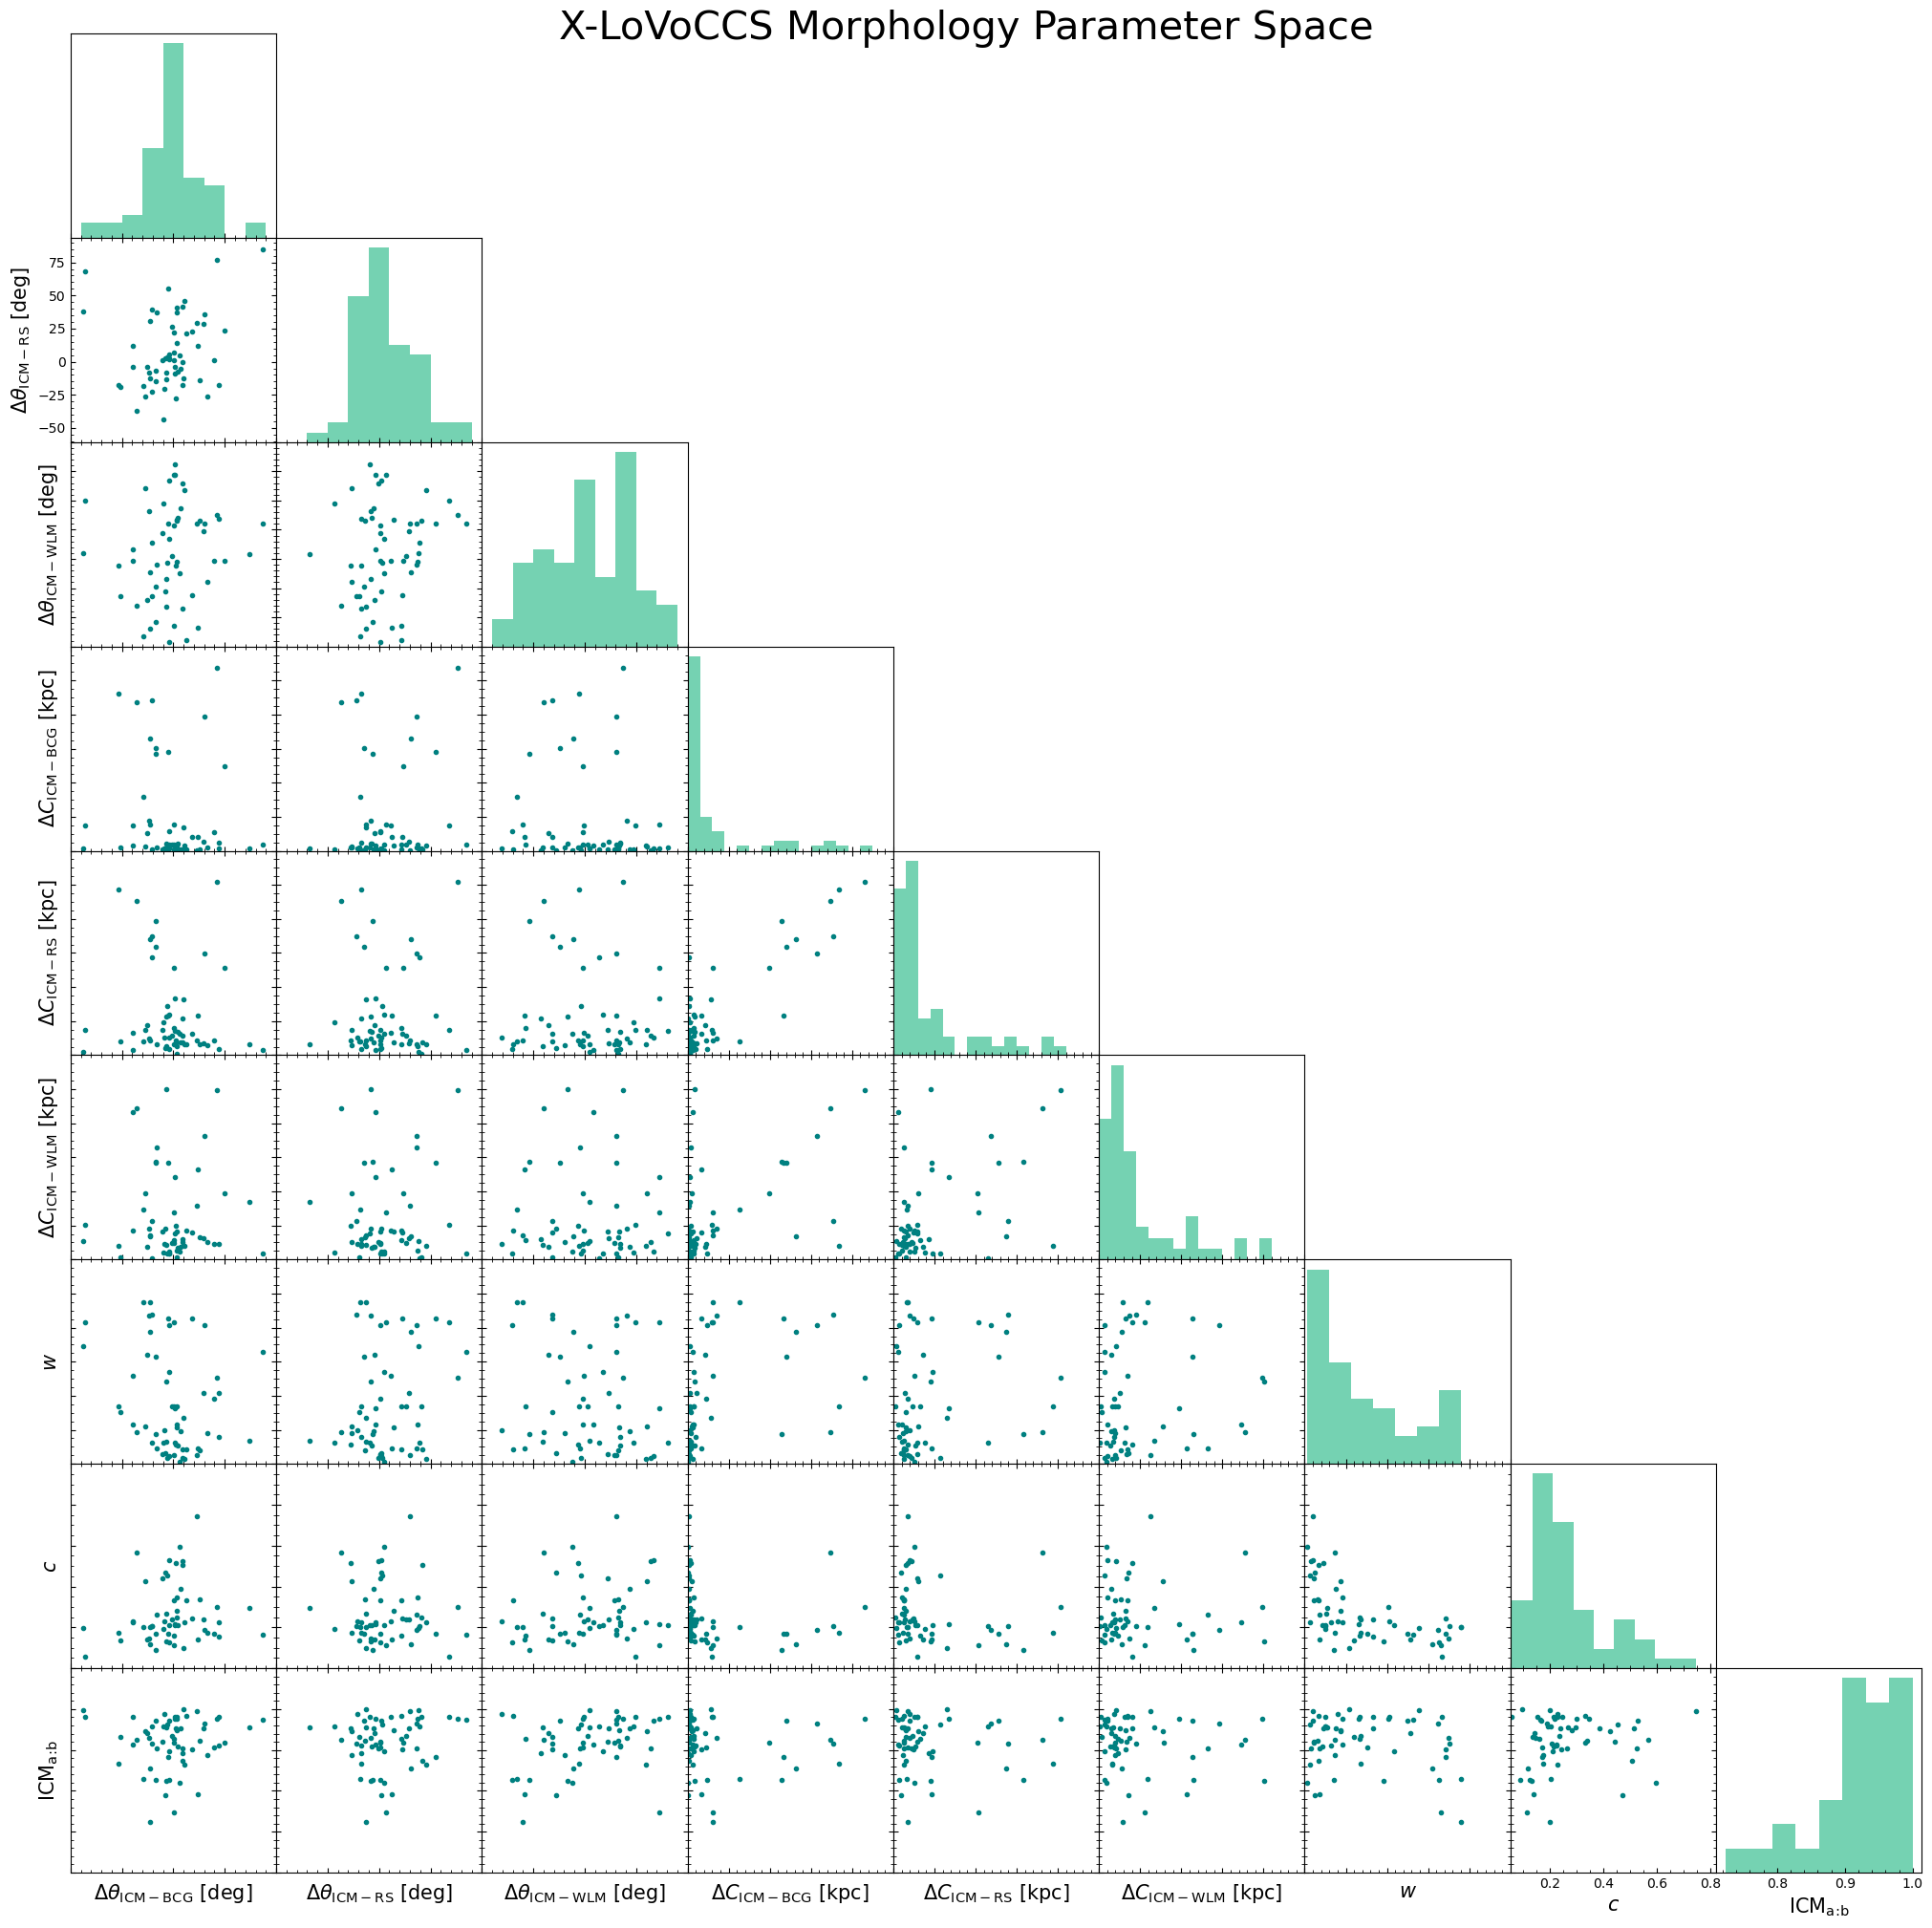

In [13]:
# Fraction to go either side of the min/max of a given parameter distribution
limit_padding = 0.1

# Colour to use globally for these data
glob_colour = "teal"
hist_colour = "mediumaquamarine"

fig, ax_arr = plt.subplots(figsize=(25, 25), sharex=False, sharey=False, ncols=len(par_names), nrows=len(par_names))
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)

lims = np.vstack([np.nanmin(xlovoccs_samp[par_names].values, axis=0)*(1-limit_padding), 
                  np.nanmax(xlovoccs_samp[par_names].values, axis=0)*(1+limit_padding)]).T

for m, subplot in np.ndenumerate(ax_arr):
    cur_x_par_name = par_names[m[1]]
    cur_y_par_name = par_names[m[0]]

    cur_x_vals = xlovoccs_samp[cur_x_par_name].values
    cur_y_vals = xlovoccs_samp[cur_y_par_name].values

    cur_x_lims = lims[m[1], :]
    cur_y_lims = lims[m[0], :]
    
    if m[0] < m[1]:
        subplot.axis('off')
        
    elif m[0] > m[1]:
        subplot.minorticks_on()
        subplot.tick_params(axis='both', direction='in', which='both', top=True, right=True)

        ax_arr[m].plot(cur_x_vals, cur_y_vals, '.', color=glob_colour)

        ax_arr[m].set_xlim(cur_x_lims)
        ax_arr[m].set_ylim(cur_y_lims)
        
        if m[0] == (len(par_names) - 1):
            ax_arr[m].set_xlabel(par_labels[cur_x_par_name], fontsize=15)
            ax_arr[m].sharex(ax_arr[(m[0]-1, m[1])])
        else:
            ax_arr[m].set_xticks(ax_arr[m].get_xticks(), [])
        
        if m[1] == 0:
            ax_arr[m].set_ylabel(par_labels[cur_y_par_name], fontsize=15)
            if m[0] != 1:
                ax_arr[m].sharey(ax_arr[(m[0], m[1]+1)])    
        else:
            ax_arr[m].set_yticks(ax_arr[m].get_yticks(), [])

    elif m[0] == m[1]:
        subplot.minorticks_on()
        subplot.tick_params(axis='both', direction='in', which='both', top=False, right=False, left=False)

        if m[0] != (len(par_names) - 1):
            ax_arr[m].sharex(ax_arr[(m[0]+1, m[1])])
        
        ax_arr[m].hist(cur_x_vals, bins=par_bins[cur_x_par_name], alpha=0.9, density=True, color=hist_colour)
        
        ax_arr[m].set_yticks([])
        
        if m[0] == (len(par_names) - 1):
            ax_arr[m].set_xlabel(par_labels[cur_x_par_name], fontsize=15)
    
fig.suptitle("X-LoVoCCS Morphology Parameter Space", fontsize=30, y=0.89, ha="center")
plt.savefig(morph_fig_path + "xlovoccs_morph_par_space_corner.pdf", bbox_inches='tight')
plt.show()

## Dimensionality reduction

To search for patterns, or similar galaxy clusters, in a semi-high dimensional parameter space, it can be useful to reduce the dimensionality of the data. There are numerous different methods that can be used to project N dimensional data into a 2D parameter space (embedding the data), we will quickly apply a few common approaches.

First, we prepare the data that we wish to use, dropping any galaxy clusters that have NaN entries for any parameters - we also use a scaling tool that transforms the input data to have mean of zero, and variance of one, as some machine-learning approaches require this.

In [14]:
all_data = xlovoccs_samp[['name']+par_names].copy()
all_data = all_data.dropna()

rel_names = all_data['name'].values
del all_data['name']

all_data = all_data.values

scaled_data = StandardScaler().fit_transform(all_data)

### UMAP

Apparently UMAP can be sensitive to non-normalised data, so here we make use of the 'standard-scaled' parameter space:

In [33]:
umap_dim_red = umap.UMAP(random_state=umap_rand_state)
umap_reduced = umap_dim_red.fit_transform(scaled_data)

/mnt/home/turne540/software/anaconda3/envs/xga_release/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


We will now visualise the new 2D embedding of our morphology parameter space - examining the structure of the embedding may lead us to find groups of galaxy clusters that are somehow similar.

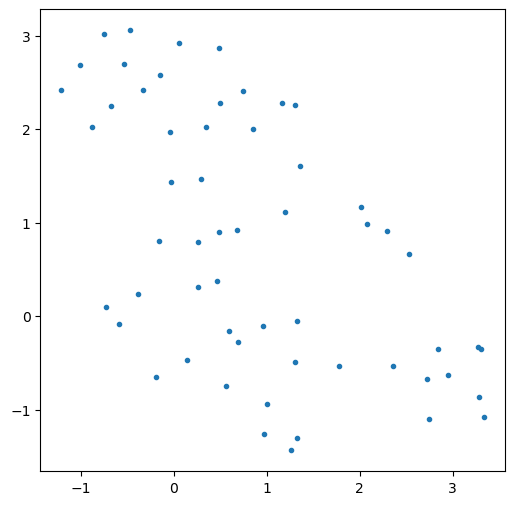

In [34]:
plt.figure(figsize=(6, 6))
plt.plot(umap_reduced[:, 0], umap_reduced[:, 1], '.')
plt.show()

### t-SNE

This technique is apparently less sensitive to the data being normalised/scaled, so we try using the original morphology parameter space:

In [83]:
tsne_dim_red = TSNE(perplexity=5, random_state=tsne_rand_state)
tsne_reduced = tsne_dim_red.fit_transform(all_data)

We once again visualize the 2D embedding of the morphology parameter space, for the same reasons. In this instance, we note that there appear to be some more distinctive groups of data points. In theory these data points should be close to one another in the multi-dimensional morphology parameter space - we highlight several groups of data points identified by eye:

In [84]:
tsne_manual_assoc_bnds = {'1': {'bnd': [[16, 30], [-34, -20]], 'color': 'teal'},
                          '2': {'bnd': [[-6, 4], [-18, -9]], 'color': 'firebrick'},
                          '3': {'bnd': [[12, 26], [8, 20]], 'color': 'peru'}
                         }

tsne_manual_assoc_inds = {}
# Sometimes it is just easier to write a for loop
for assoc_name, assoc_info in tsne_manual_assoc_bnds.items():
    assoc_bnds = assoc_info['bnd']
    cur_inds = np.argwhere(((tsne_reduced[:, 0] <=assoc_bnds[0][1]) & (tsne_reduced[:, 0] > assoc_bnds[0][0])) &
                           ((tsne_reduced[:, 1] <=assoc_bnds[1][1]) & (tsne_reduced[:, 1] > assoc_bnds[1][0]))).flatten()
    tsne_manual_assoc_inds[assoc_name] = cur_inds

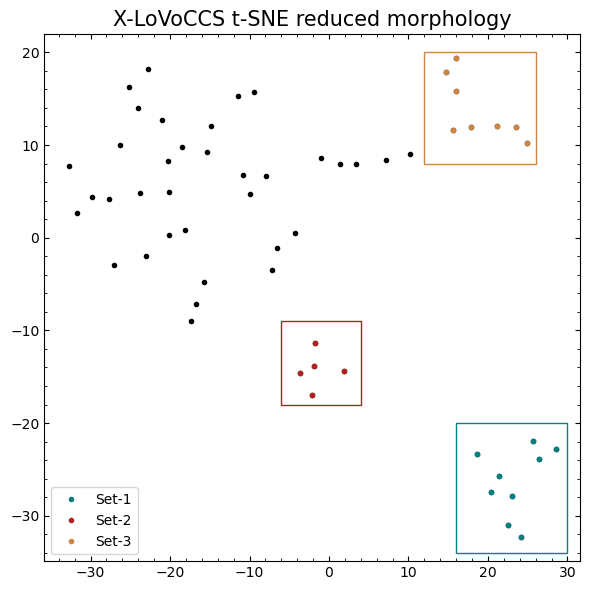

In [85]:
plt.figure(figsize=(6, 6))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.plot(tsne_reduced[:, 0], tsne_reduced[:, 1], '.', color='black')

for assoc_name, assoc_info in tsne_manual_assoc_bnds.items():
    assoc_bnds = assoc_info['bnd']
    cur_assoc_inds = tsne_manual_assoc_inds[assoc_name]
    
    cur_rect = Rectangle([assoc_bnds[0][0], assoc_bnds[1][0]], 
                         assoc_bnds[0][1]-assoc_bnds[0][0],
                         assoc_bnds[1][1]-assoc_bnds[1][0],
                         fc='none', ec=assoc_info['color'])
    plt.gca().add_artist(cur_rect)

    # Bit wasteful, but I'll just plot over those data points
    
    plt.plot(tsne_reduced[cur_assoc_inds, 0], tsne_reduced[cur_assoc_inds, 1], '.', color=assoc_info['color'], 
             label="Set-"+assoc_name)

plt.title('X-LoVoCCS t-SNE reduced morphology', fontsize=15)

plt.legend()
plt.tight_layout()
plt.show()

Names of the clusters selected in each set:

In [78]:
for assoc_name, assoc_inds in tsne_manual_assoc_inds.items():
    print("Set-" + assoc_name)
    for lov_name in rel_names[assoc_inds]:
        print(lov_name)
    print('')

Set-1
LoVoCCS-11
LoVoCCS-41B
LoVoCCS-46B
LoVoCCS-48B
LoVoCCS-60A
LoVoCCS-66B
LoVoCCS-93B
LoVoCCS-121
LoVoCCS-123

Set-2
LoVoCCS-9
LoVoCCS-46C
LoVoCCS-46A
LoVoCCS-61
LoVoCCS-65

Set-3
LoVoCCS-24
LoVoCCS-39
LoVoCCS-41A
LoVoCCS-45
LoVoCCS-51
LoVoCCS-60B
LoVoCCS-75
LoVoCCS-93A



## Searching for similar galaxy clusters using unsupervised point-clustering

### Affinity Propagation - tSNE embedding

In [101]:
aff_pr_tsne = AffinityPropagation()
aff_pr_tsne = aff_pr.fit(tsne_reduced)

In [102]:
tsne_aff_num_pnt_clst = len(aff_pr_tsne.cluster_centers_indices_)
tsne_aff_num_members = np.unique(aff_pr_tsne.labels_, return_counts=True)[1]
tsne_aff_pnt_membership = aff_pr_tsne.labels_

print("Identified point clusters -", tsne_aff_num_pnt_clst, '\n')

for clst_ind, clst_cent_ind in enumerate(aff_pr_tsne.cluster_centers_indices_):
    print('PC-'+str(clst_ind), '[{n} members] center - {c}'.format(c=rel_names[clst_cent_ind], 
                                                                   n=tsne_aff_num_members[clst_ind]))

Identified point clusters - 5 

PC-0 [13 members] center - LoVoCCS-15
PC-1 [10 members] center - LoVoCCS-45
PC-2 [5 members] center - LoVoCCS-61
PC-3 [20 members] center - LoVoCCS-74
PC-4 [9 members] center - LoVoCCS-121


Name of the galaxy clusters in each point cluster:

In [136]:
for clst_ind in range(0, tsne_aff_num_pnt_clst):
    cur_memb_inds = np.argwhere(tsne_aff_pnt_membership == clst_ind).flatten()
    cur_lov_names = rel_names[cur_memb_inds]
    print("PC-" + str(clst_ind))
    for lov_name in cur_lov_names:
        print(lov_name)
    print('')

PC-0
LoVoCCS-1
LoVoCCS-14
LoVoCCS-15
LoVoCCS-21
LoVoCCS-22
LoVoCCS-27
LoVoCCS-30
LoVoCCS-31
LoVoCCS-49
LoVoCCS-58
LoVoCCS-63
LoVoCCS-119
LoVoCCS-131

PC-1
LoVoCCS-24
LoVoCCS-35
LoVoCCS-39
LoVoCCS-41A
LoVoCCS-45
LoVoCCS-48A
LoVoCCS-51
LoVoCCS-60B
LoVoCCS-75
LoVoCCS-93A

PC-2
LoVoCCS-9
LoVoCCS-46C
LoVoCCS-46A
LoVoCCS-61
LoVoCCS-65

PC-3
LoVoCCS-2
LoVoCCS-5
LoVoCCS-7
LoVoCCS-10
LoVoCCS-12
LoVoCCS-13
LoVoCCS-18
LoVoCCS-26
LoVoCCS-28
LoVoCCS-29
LoVoCCS-42
LoVoCCS-66A
LoVoCCS-67
LoVoCCS-74
LoVoCCS-80
LoVoCCS-85
LoVoCCS-89
LoVoCCS-94
LoVoCCS-98
LoVoCCS-99

PC-4
LoVoCCS-11
LoVoCCS-41B
LoVoCCS-46B
LoVoCCS-48B
LoVoCCS-60A
LoVoCCS-66B
LoVoCCS-93B
LoVoCCS-121
LoVoCCS-123



We visualise the clustered clusters:

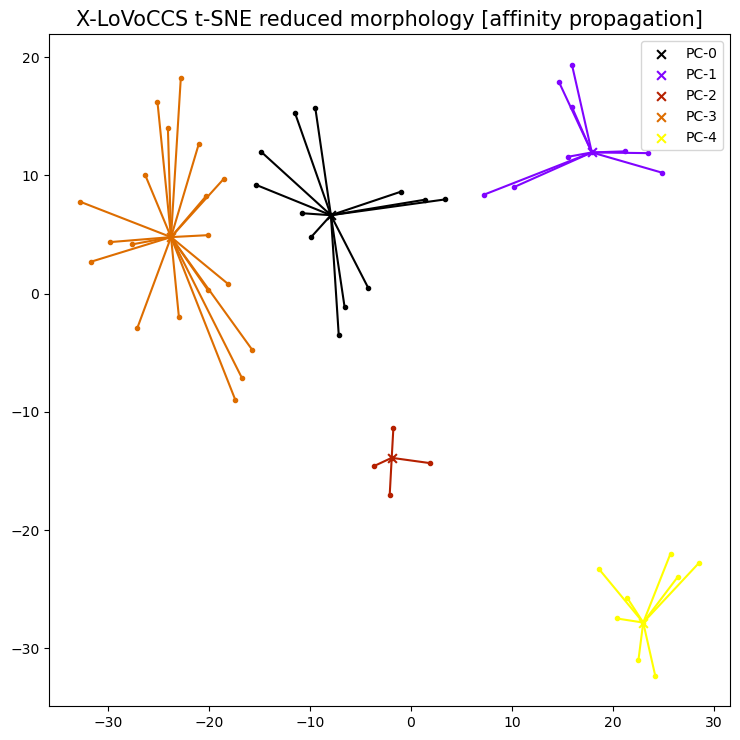

In [143]:
plt.figure(figsize=(7.5, 7.5))

colors = plt.cycler("color", plt.cm.gnuplot(np.linspace(0, 1, tsne_aff_num_pnt_clst)))

for k, col in zip(range(tsne_aff_num_pnt_clst), colors):
    class_members = labels == k
    cluster_center = tsne_reduced[aff_pr_tsne.cluster_centers_indices_[k]]
    plt.scatter(tsne_reduced[class_members, 0], tsne_reduced[class_members, 1], color=col["color"], marker=".")
    plt.scatter(cluster_center[0], cluster_center[1], s=40, color=col["color"], marker="x", label="PC-"+str(k))
    
    for x in tsne_reduced[class_members]:
        plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"])

plt.title('X-LoVoCCS t-SNE reduced morphology [affinity propagation]', fontsize=15)

plt.legend()
plt.tight_layout()
plt.show()

### K-means clustering - tSNE embedding

In [128]:
kmeans_tsne_num_clust = 3

kmeans_tsne = KMeans(kmeans_tsne_num_clust)
kmeans_tsne = kmeans_tsne.fit(tsne_reduced)

In [129]:
tsne_kmeans_num_members = np.unique(kmeans_tsne.labels_, return_counts=True)[1]
tsne_kmeans_pnt_membership = kmeans_tsne.labels_

for clst_ind in range(0, kmeans_tsne_num_clust):
    print('PC-'+str(clst_ind), '[{n} members]'.format(n=tsne_kmeans_num_members[clst_ind]))

PC-0 [30 members]
PC-1 [13 members]
PC-2 [14 members]


In [137]:
for clst_ind in range(0, kmeans_tsne_num_clust):
    cur_memb_inds = np.argwhere(tsne_kmeans_pnt_membership == clst_ind).flatten()
    cur_lov_names = rel_names[cur_memb_inds]
    print("PC-" + str(clst_ind))
    for lov_name in cur_lov_names:
        print(lov_name)
    print('')

PC-0
LoVoCCS-1
LoVoCCS-2
LoVoCCS-5
LoVoCCS-7
LoVoCCS-10
LoVoCCS-12
LoVoCCS-13
LoVoCCS-14
LoVoCCS-15
LoVoCCS-18
LoVoCCS-21
LoVoCCS-26
LoVoCCS-27
LoVoCCS-28
LoVoCCS-29
LoVoCCS-30
LoVoCCS-31
LoVoCCS-42
LoVoCCS-58
LoVoCCS-63
LoVoCCS-66A
LoVoCCS-67
LoVoCCS-74
LoVoCCS-80
LoVoCCS-85
LoVoCCS-89
LoVoCCS-94
LoVoCCS-98
LoVoCCS-99
LoVoCCS-119

PC-1
LoVoCCS-22
LoVoCCS-24
LoVoCCS-35
LoVoCCS-39
LoVoCCS-41A
LoVoCCS-45
LoVoCCS-48A
LoVoCCS-49
LoVoCCS-51
LoVoCCS-60B
LoVoCCS-75
LoVoCCS-93A
LoVoCCS-131

PC-2
LoVoCCS-9
LoVoCCS-11
LoVoCCS-41B
LoVoCCS-46B
LoVoCCS-46C
LoVoCCS-46A
LoVoCCS-48B
LoVoCCS-60A
LoVoCCS-61
LoVoCCS-65
LoVoCCS-66B
LoVoCCS-93B
LoVoCCS-121
LoVoCCS-123



We visualise the point cluster memberships identified by K-means:

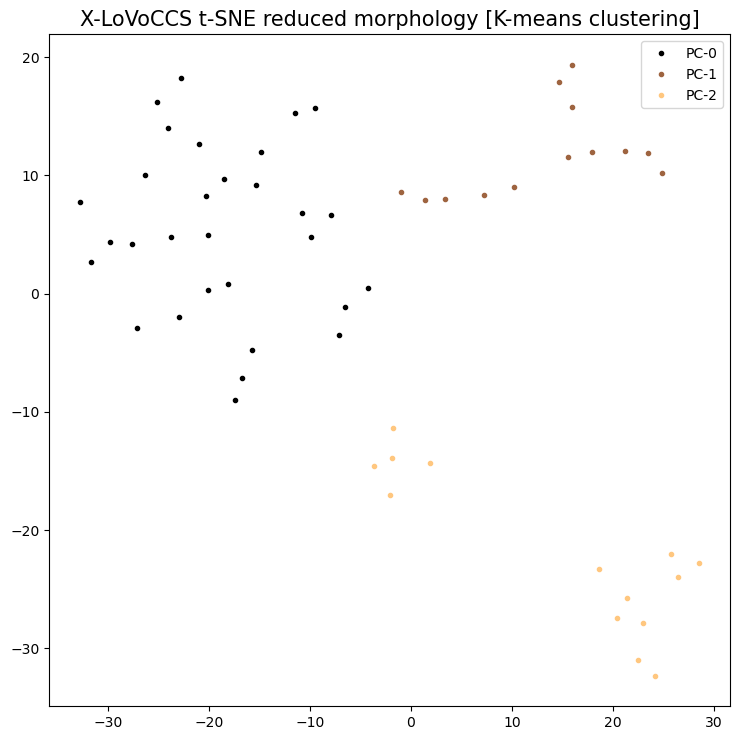

In [144]:
plt.figure(figsize=(7.5, 7.5))

colors = plt.cycler("color", plt.cm.copper(np.linspace(0, 1, kmeans_tsne_num_clust)))
for k, col in zip(range(kmeans_tsne_num_clust), colors):
    cur_sel = np.argwhere(tsne_kmeans_pnt_membership == k).flatten()

    plt.plot(tsne_reduced[cur_sel, 0], tsne_reduced[cur_sel, 1], '.', color=col['color'], label='PC-'+str(k))

plt.title('X-LoVoCCS t-SNE reduced morphology [K-means clustering]', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()